##### Using adjacency list to represent a graph:

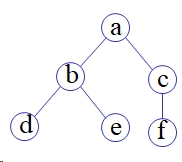

In [1]:
# Example 1: defining a graph in python using an adjacency list

tree = {'a': ['b', 'c'], 'b': ['d', 'e'], 'c': ['f'], 'd': [], 'e': [], 'f': []}

for key, val in tree.items():
        print(key, " is connected to ", val)

a  is connected to  ['b', 'c']
b  is connected to  ['d', 'e']
c  is connected to  ['f']
d  is connected to  []
e  is connected to  []
f  is connected to  []


##### Using adjacency matrix to represent a directed graph
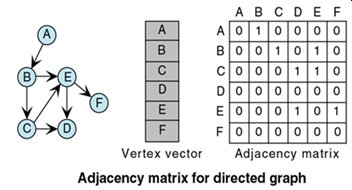

In [4]:
# Example 2: Defining a graph in python using an adjacency matrix

a_digraph = { 'v': "", 'e': ""}
a_digraph['v'] = ['a', 'b', 'c', 'd', 'e', 'f']
a_digraph['e'] = [[0, 1, 0, 0, 0, 0],
[0, 0, 1, 0, 1, 0],
[0, 0, 0, 1, 1, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 1],
[0, 0, 0, 0, 0, 0]]

for vert in a_digraph['v']:
    print(vert)

a
b
c
d
e
f


In [6]:
for vert in a_digraph['v']:
    position = a_digraph['v'].index(vert)
    print(vert, ':', position)


a : 0
b : 1
c : 2
d : 3
e : 4
f : 5


In [8]:
vpos ={}
for vert in a_digraph['v']:
    vpos[vert] = a_digraph['v'].index(vert)
print(vpos)


{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5}


In [10]:
for neighbors in a_digraph['e']:
  my_neighbors = [index for index, value in enumerate(neighbors) if value != 0]
  print(my_neighbors)

[1]
[2, 4]
[3, 4]
[]
[3, 5]
[]


##### The following is for reference on how to use NetworkX for using graphs.
##### NetworkX is a powerful library useful to define graphs;
#####  It provides several fucntions that are useful to model porblems using graphs, and solve them using very efficient algorithms.

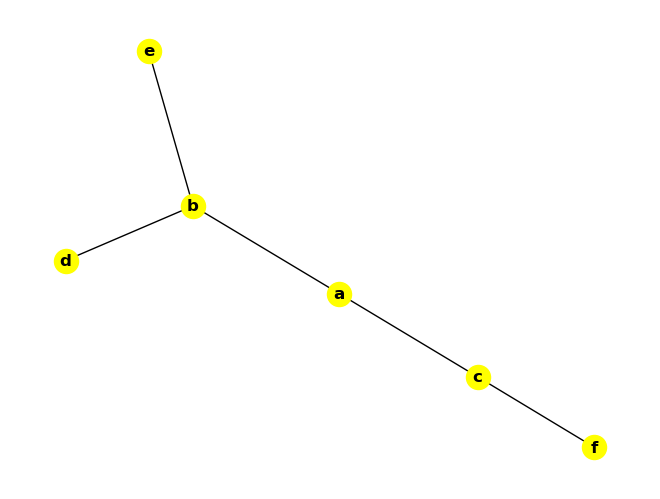

In [13]:
import matplotlib.pyplot as plt
import networkx as nx

# Using NetworkX to dfine the same graph as Example 1.
G = nx.Graph()

G.add_nodes_from(['a', 'b', 'c', 'd', 'e', 'f'])
G.add_edges_from([('a', 'b'), ('a', 'c'),('b', 'd'),('b', 'e'),('c', 'f')])

# Draw a figure showing the graph. Convince yourself that this is the same graph as in Example 1.

nx.draw(G, with_labels=True, node_color='yellow', font_weight='bold')

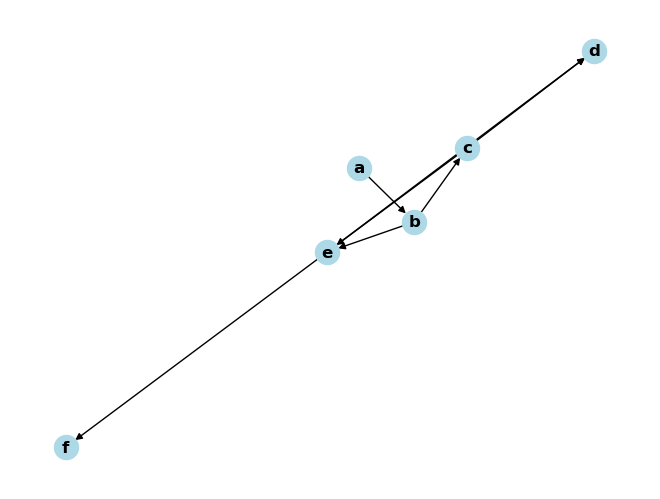

In [15]:
# Using NetworkX to define a Directed Graph

DG = nx.DiGraph()

DG.add_nodes_from(['a', 'b', 'c', 'd', 'e', 'f'])
DG.add_edges_from([('a', 'b'), ('b', 'c'),('b', 'e'),('c', 'd'),('c', 'e'),('e', 'd'),('e', 'f')])

# Draw a figure showing the Directed graph in Exmaple 2. Again, pelase test thst the two graphs are the same.
nx.draw(DG, with_labels=True, node_color='lightblue', font_weight='bold')

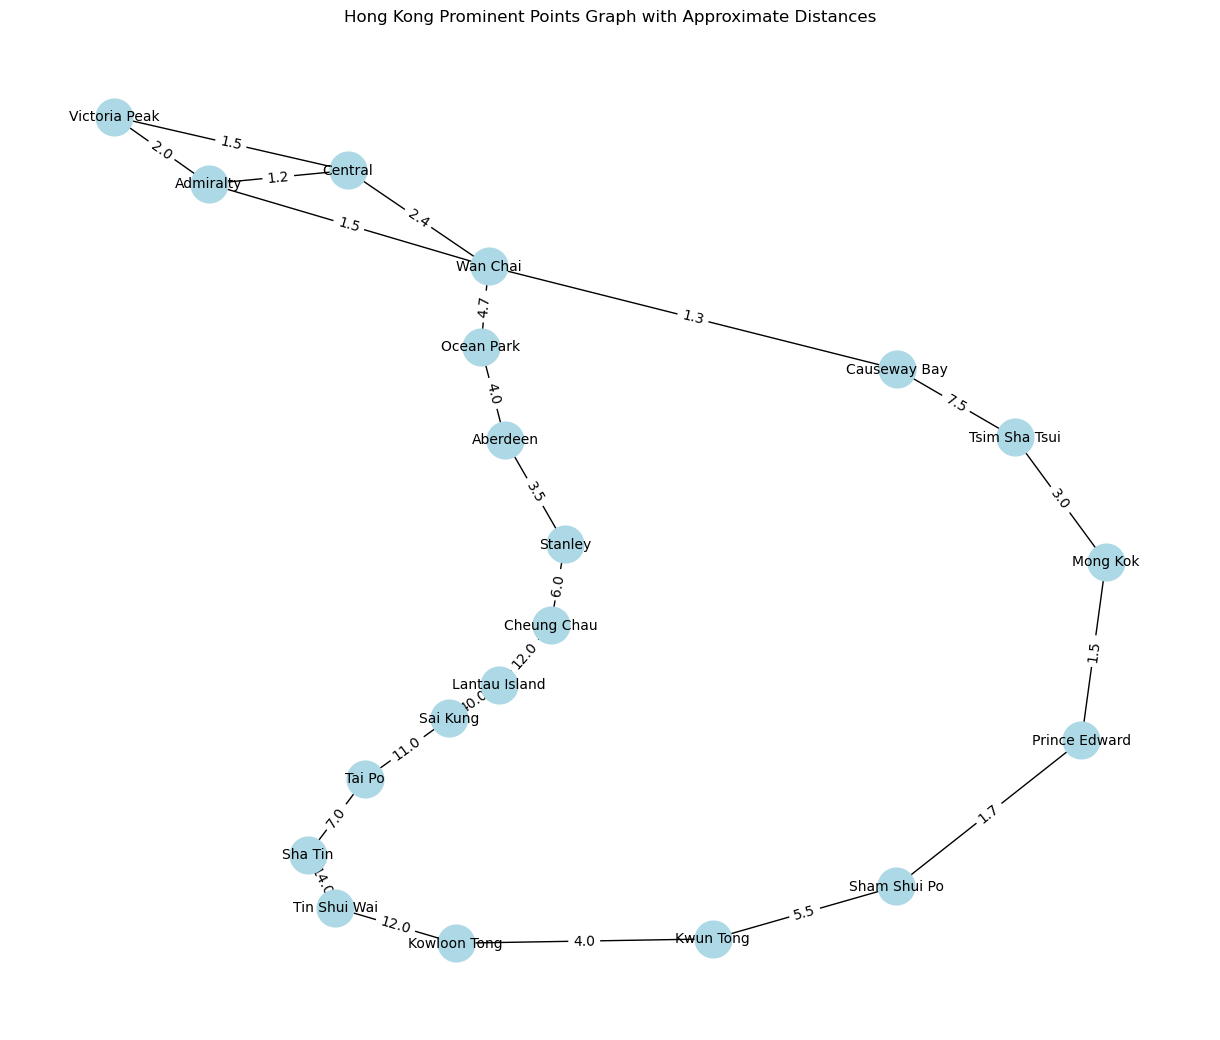

Shortest path from Victoria Peak to Tin Shui Wai: ['Victoria Peak', 'Admiralty', 'Wan Chai', 'Causeway Bay', 'Tsim Sha Tsui', 'Mong Kok', 'Prince Edward', 'Sham Shui Po', 'Kwun Tong', 'Kowloon Tong', 'Tin Shui Wai']
Total distance: 40.0 km


In [17]:
# Example 3: Finding shortest paths
HKG = nx.Graph()

# Step 2: Add nodes roughly representing prominent points in Hong Kong
places = [
    "Victoria Peak", "Central", "Admiralty", "Wan Chai", "Causeway Bay",
    "Tsim Sha Tsui", "Mong Kok", "Prince Edward", "Sham Shui Po", "Kwun Tong",
    "Kowloon Tong", "Tin Shui Wai", "Sha Tin", "Tai Po", "Sai Kung",
    "Lantau Island", "Cheung Chau", "Stanley", "Aberdeen", "Ocean Park"
]

HKG.add_nodes_from(places)

# Step 3: Add weighted edges representing approximate distances (in km) between these points
roads = [
    ("Victoria Peak", "Central", 1.5), ("Victoria Peak", "Admiralty", 2.0),
    ("Central", "Admiralty", 1.2), ("Central", "Wan Chai", 2.4),
    ("Admiralty", "Wan Chai", 1.5), ("Wan Chai", "Causeway Bay", 1.3),
    ("Causeway Bay", "Tsim Sha Tsui", 7.5), ("Tsim Sha Tsui", "Mong Kok", 3.0),
    ("Mong Kok", "Prince Edward", 1.5), ("Prince Edward", "Sham Shui Po", 1.7),
    ("Sham Shui Po", "Kwun Tong", 5.5), ("Kwun Tong", "Kowloon Tong", 4.0),
    ("Kowloon Tong", "Tin Shui Wai", 12.0), ("Tin Shui Wai", "Sha Tin", 14.0),
    ("Sha Tin", "Tai Po", 7.0), ("Tai Po", "Sai Kung", 11.0),
    ("Sai Kung", "Lantau Island", 40.0), ("Lantau Island", "Cheung Chau", 12.0),
    ("Cheung Chau", "Stanley", 6.0), ("Stanley", "Aberdeen", 3.5),
    ("Aberdeen", "Ocean Park", 4.0), ("Ocean Park", "Wan Chai", 4.7)
]

HKG.add_weighted_edges_from(roads)

# Visualize the graph using matplotlib
pos = nx.spring_layout(HKG, seed=42)
plt.figure(figsize=(12, 10))
nx.draw(HKG, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10)
edge_labels = nx.get_edge_attributes(HKG, 'weight')
nx.draw_networkx_edge_labels(HKG, pos, edge_labels=edge_labels)
plt.title('Hong Kong Prominent Points Graph with Approximate Distances')
plt.show()

# Step 4: Use Dijkstra's algorithm to find the shortest path between two nodes
start_node = "Victoria Peak"
end_node = "Tin Shui Wai"

shortest_path = nx.dijkstra_path(HKG, start_node, end_node)
shortest_path_length = nx.dijkstra_path_length(HKG, start_node, end_node)

print(f"Shortest path from {start_node} to {end_node}: {shortest_path}")
print(f"Total distance: {shortest_path_length} km")

Exercise 1. [4 points] Create an example like the one above, by using an AI engine (e.g. HKUST GenAI platform, or Perplexity, or DeepSeek).

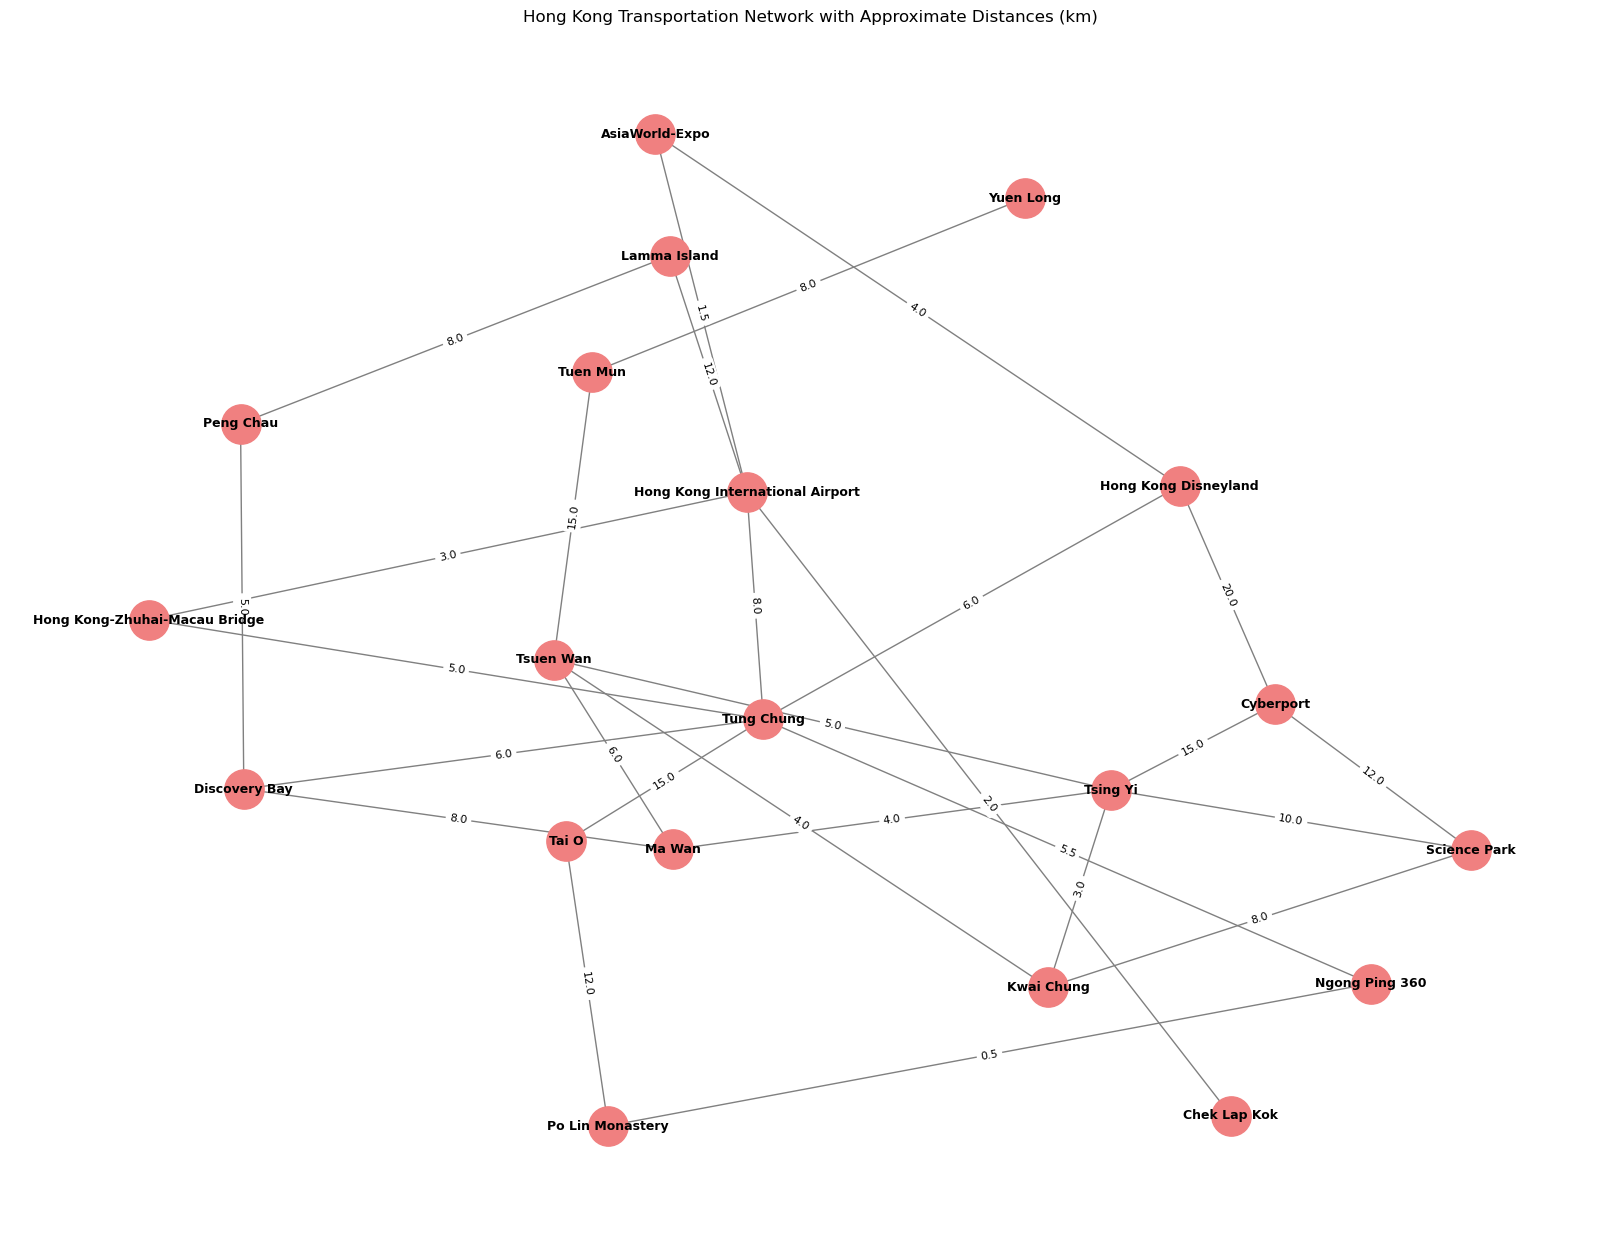

Shortest path from Hong Kong International Airport to Hong Kong Disneyland:
Hong Kong International Airport -> AsiaWorld-Expo -> Hong Kong Disneyland
Total distance: 5.5 km


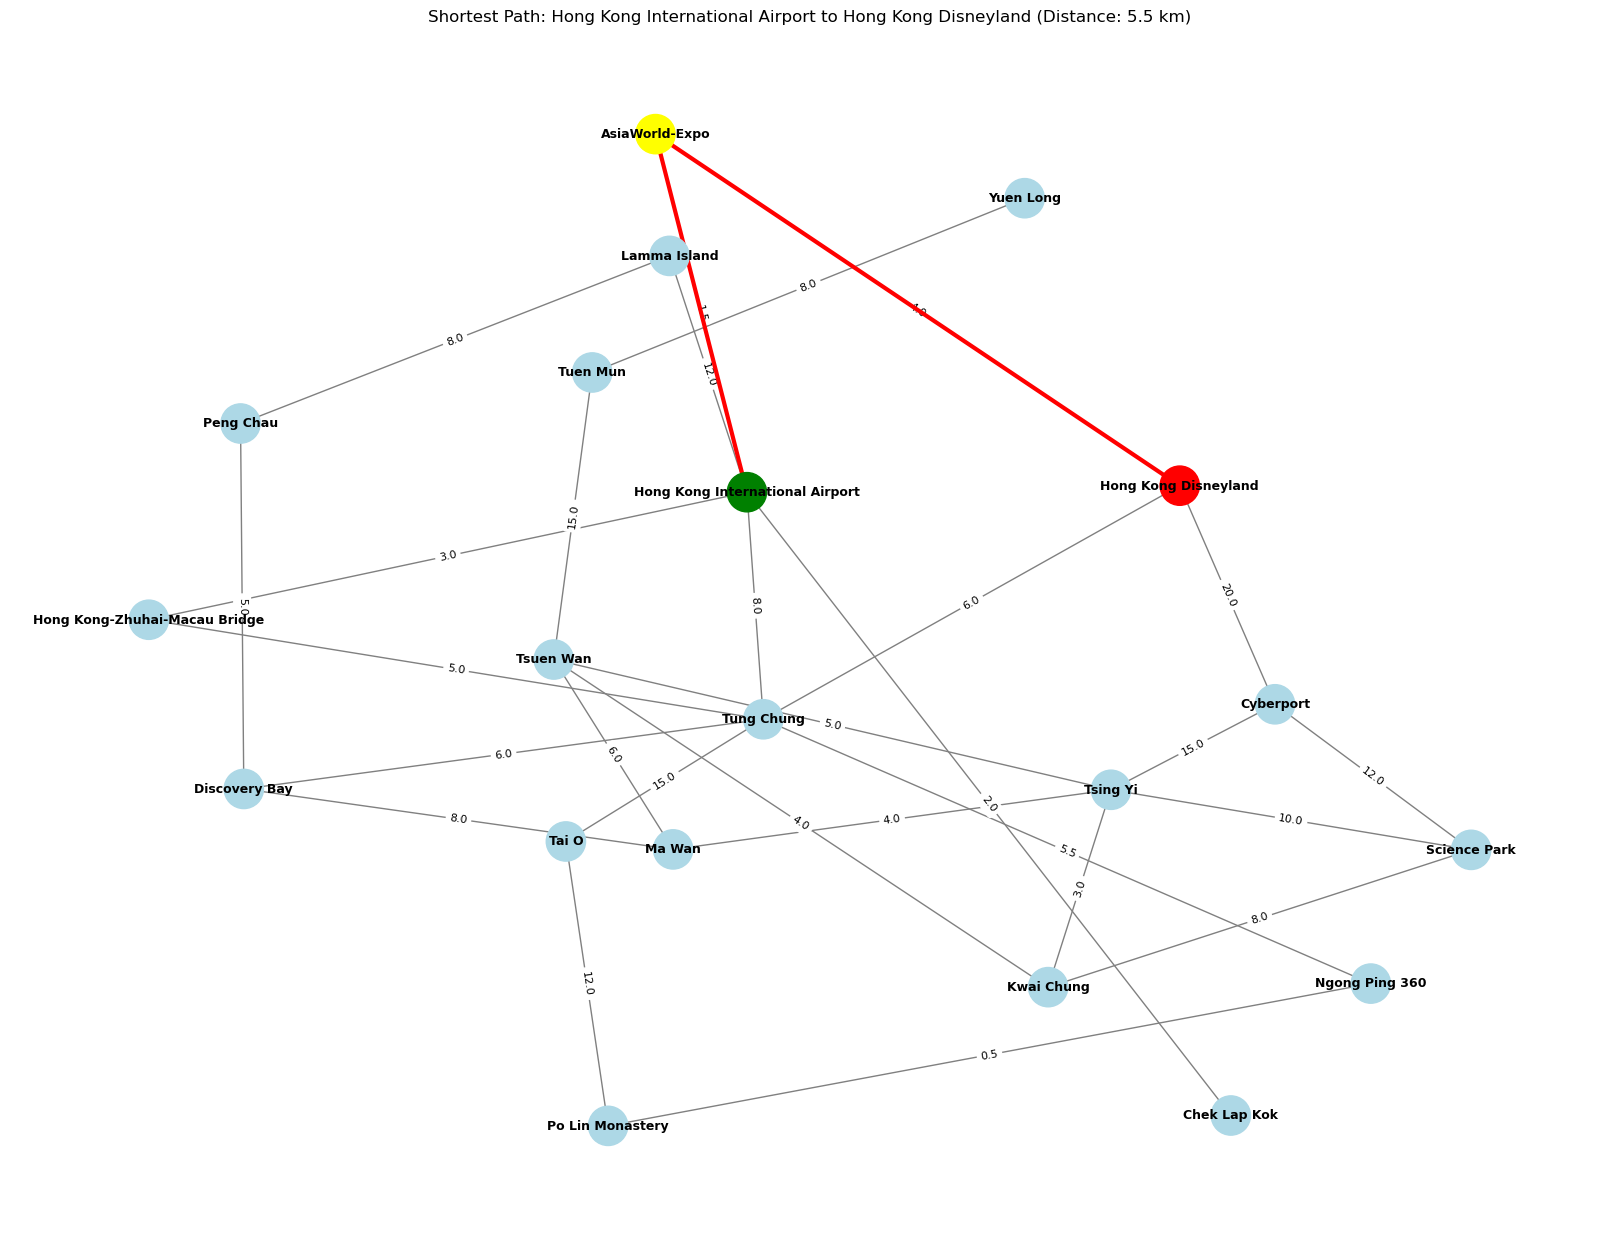


--- Additional Shortest Path Calculations ---

Path from Hong Kong International Airport to Cyberport: 25.5 km
Hong Kong International Airport -> AsiaWorld-Expo -> Hong Kong Disneyland -> Cyberport

Path from Tai O to Science Park: 43.0 km
Tai O -> Tung Chung -> Discovery Bay -> Ma Wan -> Tsing Yi -> Science Park

--- Graph Statistics ---
Number of nodes: 20
Number of edges: 28
Graph density: 0.147
Is connected: True

Most connected locations (by degree centrality):
  Tung Chung: 0.316
  Hong Kong International Airport: 0.263
  Tsing Yi: 0.263
  Tsuen Wan: 0.211
  Discovery Bay: 0.158


In [19]:
## Test your code here

import numpy as np

# Create a new Hong Kong graph with different locations
HKG2 = nx.Graph()

# Step 2: Add 20 different prominent points in Hong Kong
new_places = [
    "Hong Kong International Airport", "Tsing Yi", "Tsuen Wan", "Tuen Mun", "Yuen Long",
    "Tai O", "Tung Chung", "Discovery Bay", "Ma Wan", "Kwai Chung",
    "Chek Lap Kok", "Hong Kong-Zhuhai-Macau Bridge", "Lamma Island", "Peng Chau", "Po Lin Monastery",
    "Ngong Ping 360", "AsiaWorld-Expo", "Hong Kong Disneyland", "Cyberport", "Science Park"
]

HKG2.add_nodes_from(new_places)

# Step 3: Add weighted edges representing approximate distances (in km) between these points
new_roads = [
    # Airport area connections
    ("Hong Kong International Airport", "Tung Chung", 8.0),
    ("Hong Kong International Airport", "AsiaWorld-Expo", 1.5),
    ("Hong Kong International Airport", "Chek Lap Kok", 2.0),
    
    # Lantau Island connections
    ("Tung Chung", "Tai O", 15.0),
    ("Tung Chung", "Ngong Ping 360", 5.5),
    ("Ngong Ping 360", "Po Lin Monastery", 0.5),
    ("Tai O", "Po Lin Monastery", 12.0),
    
    # Islands connections
    ("Discovery Bay", "Tung Chung", 6.0),
    ("Discovery Bay", "Ma Wan", 8.0),
    ("Ma Wan", "Tsing Yi", 4.0),
    ("Lamma Island", "Hong Kong International Airport", 12.0),
    ("Peng Chau", "Discovery Bay", 5.0),
    
    # New Territories connections
    ("Tsing Yi", "Kwai Chung", 3.0),
    ("Tsing Yi", "Tsuen Wan", 5.0),
    ("Tsuen Wan", "Tuen Mun", 15.0),
    ("Tuen Mun", "Yuen Long", 8.0),
    
    # Infrastructure connections
    ("Hong Kong-Zhuhai-Macau Bridge", "Hong Kong International Airport", 3.0),
    ("Hong Kong-Zhuhai-Macau Bridge", "Tung Chung", 5.0),
    
    # Entertainment and business areas
    ("Hong Kong Disneyland", "Tung Chung", 6.0),
    ("Hong Kong Disneyland", "AsiaWorld-Expo", 4.0),
    ("Cyberport", "Hong Kong Disneyland", 20.0),
    ("Science Park", "Cyberport", 12.0),
    ("Science Park", "Tsing Yi", 10.0),
    ("Kwai Chung", "Science Park", 8.0),
    
    # Additional connections to make the graph more connected
    ("Yuen Long", "Tuen Mun", 8.0),
    ("Tsuen Wan", "Kwai Chung", 4.0),
    ("Ma Wan", "Tsuen Wan", 6.0),
    ("Lamma Island", "Peng Chau", 8.0),
    ("Cyberport", "Tsing Yi", 15.0)
]

HKG2.add_weighted_edges_from(new_roads)

# Visualize the graph using a spring layout
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(HKG2, k=2, iterations=50, seed=42)
nx.draw(HKG2, pos, with_labels=True, node_size=800, node_color='lightcoral', 
        font_size=9, font_weight='bold', edge_color='gray')
edge_labels = nx.get_edge_attributes(HKG2, 'weight')
nx.draw_networkx_edge_labels(HKG2, pos, edge_labels=edge_labels, font_size=8)
plt.title('Hong Kong Transportation Network with Approximate Distances (km)')
plt.show()

# Step 4: Use Dijkstra's algorithm to find the shortest path between two nodes
start_node = "Hong Kong International Airport"
end_node = "Hong Kong Disneyland"

try:
    shortest_path = nx.dijkstra_path(HKG2, start_node, end_node)
    shortest_path_length = nx.dijkstra_path_length(HKG2, start_node, end_node)
    
    print(f"Shortest path from {start_node} to {end_node}:")
    print(" -> ".join(shortest_path))
    print(f"Total distance: {shortest_path_length} km")
    
    # Visualize the shortest path
    plt.figure(figsize=(16, 12))
    
    # Color nodes: start=green, end=red, path nodes=yellow, others=lightblue
    node_colors = []
    for node in HKG2.nodes():
        if node == start_node:
            node_colors.append('green')
        elif node == end_node:
            node_colors.append('red')
        elif node in shortest_path:
            node_colors.append('yellow')
        else:
            node_colors.append('lightblue')
    
    nx.draw(HKG2, pos, with_labels=True, node_size=800, node_color=node_colors,
            font_size=9, font_weight='bold', edge_color='gray')
    nx.draw_networkx_edge_labels(HKG2, pos, edge_labels=edge_labels, font_size=8)
    
    # Highlight the shortest path edges
    path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
    nx.draw_networkx_edges(HKG2, pos, edgelist=path_edges, edge_color='red', width=3)
    
    plt.title(f'Shortest Path: {start_node} to {end_node} (Distance: {shortest_path_length} km)')
    plt.show()
    
except nx.NetworkXNoPath:
    print(f"No path found between {start_node} and {end_node}")

# Additional analysis: Find some interesting paths
print("\n--- Additional Shortest Path Calculations ---")

# Path 2: From airport to city center (approximated by Cyberport)
start2 = "Hong Kong International Airport"
end2 = "Cyberport"

try:
    path2 = nx.dijkstra_path(HKG2, start2, end2)
    distance2 = nx.dijkstra_path_length(HKG2, start2, end2)
    print(f"\nPath from {start2} to {end2}: {distance2} km")
    print(" -> ".join(path2))
except nx.NetworkXNoPath:
    print(f"No path between {start2} and {end2}")

# Path 3: From traditional village to modern attraction
start3 = "Tai O"
end3 = "Science Park"

try:
    path3 = nx.dijkstra_path(HKG2, start3, end3)
    distance3 = nx.dijkstra_path_length(HKG2, start3, end3)
    print(f"\nPath from {start3} to {end3}: {distance3} km")
    print(" -> ".join(path3))
except nx.NetworkXNoPath:
    print(f"No path between {start3} and {end3}")

# Graph statistics
print(f"\n--- Graph Statistics ---")
print(f"Number of nodes: {HKG2.number_of_nodes()}")
print(f"Number of edges: {HKG2.number_of_edges()}")
print(f"Graph density: {nx.density(HKG2):.3f}")
print(f"Is connected: {nx.is_connected(HKG2)}")

# Calculate degree centrality to find most connected locations
degree_centrality = nx.degree_centrality(HKG2)
print(f"\nMost connected locations (by degree centrality):")
sorted_locations = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
for location, centrality in sorted_locations:
    print(f"  {location}: {centrality:.3f}")

Exercise 2.  [4 points] Modify the above example by adding three more edges to the the graph (look up the map of HKG on google maps, and pick any 3 points and find the distance between them to create the corresponding edges.)



Added three new edges to the graph:
  Tsing Yi <-> Hong Kong Disneyland: 18.0 km
  Science Park <-> Tai Po: 15.0 km
  Lamma Island <-> Cyberport: 10.0 km

--- Recalculating shortest path after adding new edges ---
New shortest path from Hong Kong International Airport to Hong Kong Disneyland:
Hong Kong International Airport -> AsiaWorld-Expo -> Hong Kong Disneyland
New total distance: 5.5 km


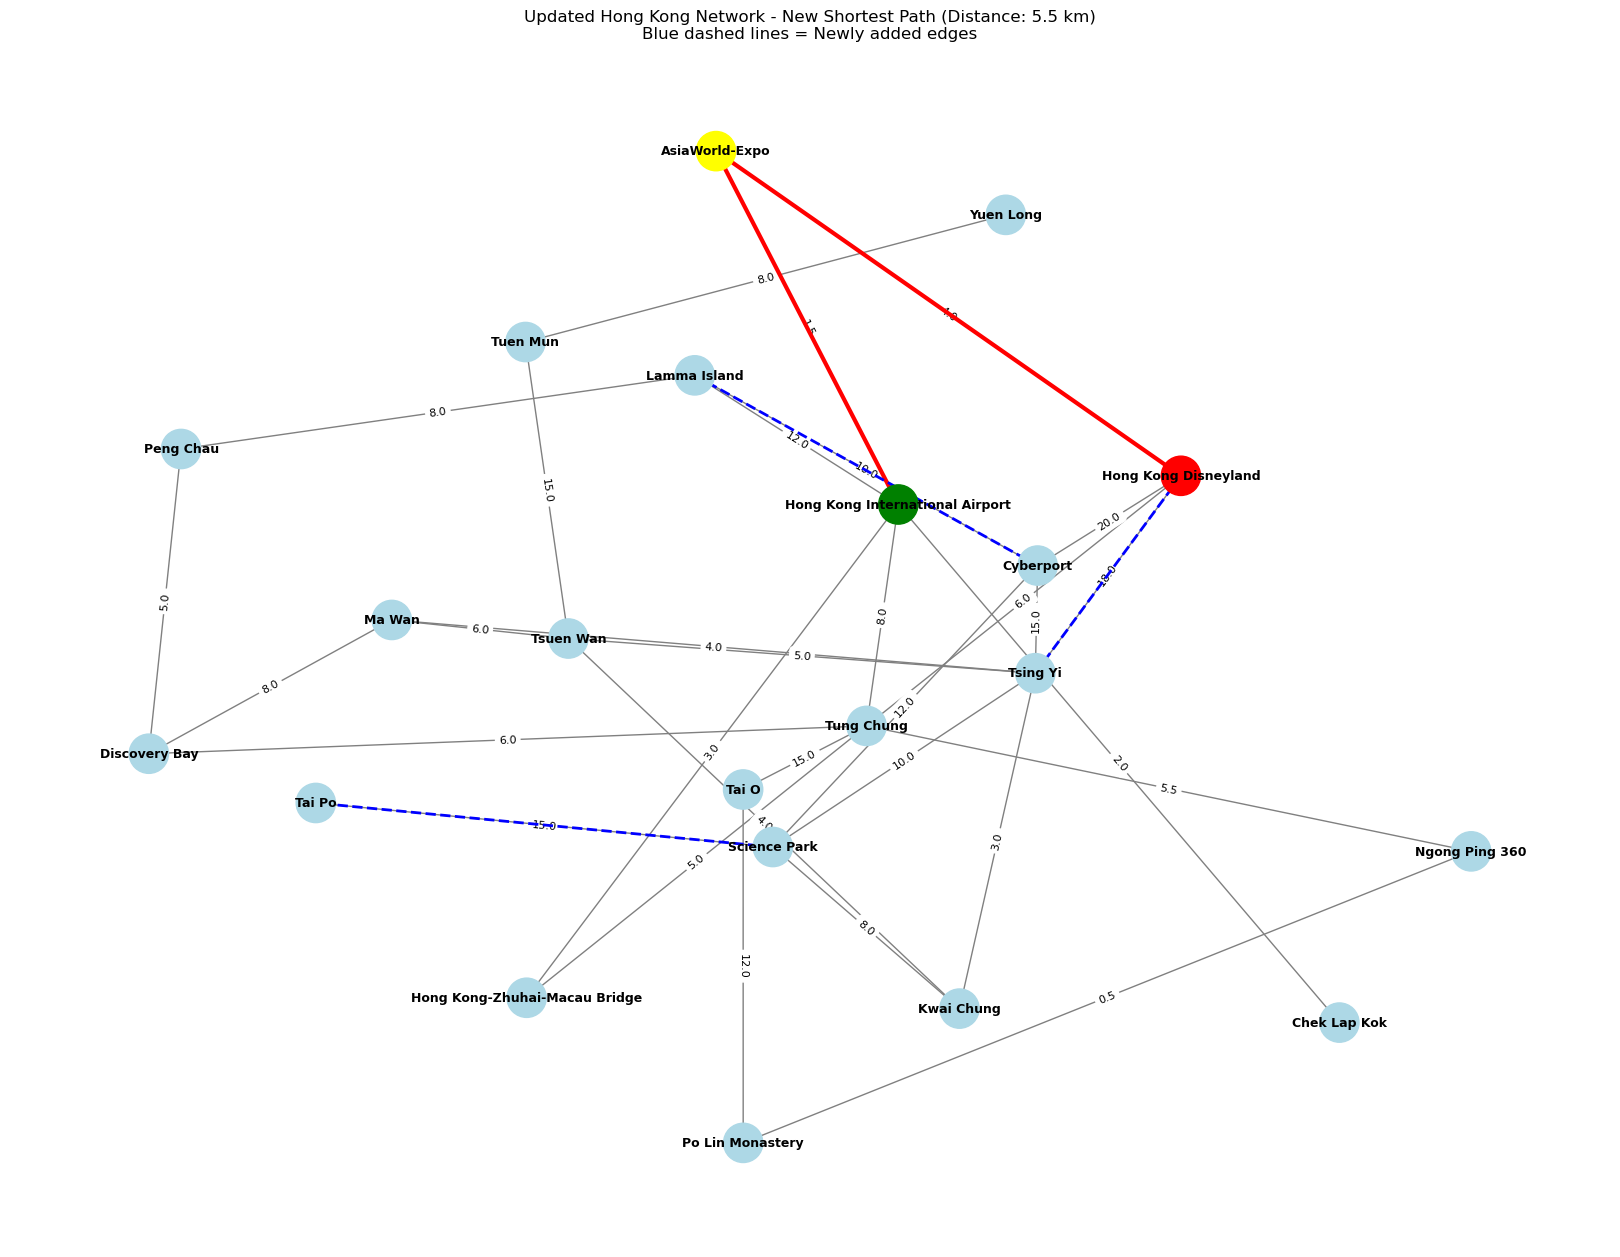


--- Testing paths using the new edges ---

Path from Science Park to Hong Kong Disneyland: 28.0 km
Science Park -> Tsing Yi -> Hong Kong Disneyland
This path does not use the new edges.

Direct path from Lamma Island to Cyberport: 10.0 km
Lamma Island -> Cyberport
This path uses the newly added direct connection!

--- Updated Graph Statistics ---
Number of nodes: 21
Number of edges: 31 (Increased by 3)
Graph density: 0.148

--- Path Comparison ---
Original path distance: 5.5 km
New path distance: 5.5 km
No change in path distance.
The path route remains the same.

--- Network Connectivity Analysis ---
Average shortest path length before: 3.079
Average shortest path length after: 2.914
Improvement in overall connectivity: 0.165

Nodes directly connected by new edges:
Edge 1: Tsing Yi <-> Hong Kong Disneyland (18.0 km)
Edge 2: Science Park <-> Tai Po (15.0 km)
Edge 3: Lamma Island <-> Cyberport (10.0 km)


In [21]:
## Write your code here.
## NOTE: If you run the code already, then you don't need to define the Graph HKG again, just add the new edges, and run the shortest path code again.

# Add three more edges to the existing Hong Kong graph
additional_roads = [
    ("Tsing Yi", "Hong Kong Disneyland", 18.0),  # Direct connection via highway
    ("Science Park", "Tai Po", 15.0),           # Connection through New Territories
    ("Lamma Island", "Cyberport", 10.0)         # Ferry connection
]

HKG2.add_weighted_edges_from(additional_roads)

print("Added three new edges to the graph:")
for road in additional_roads:
    print(f"  {road[0]} <-> {road[1]}: {road[2]} km")

# Re-run the shortest path analysis with the same nodes
start_node = "Hong Kong International Airport"
end_node = "Hong Kong Disneyland"

print(f"\n--- Recalculating shortest path after adding new edges ---")

try:
    shortest_path_new = nx.dijkstra_path(HKG2, start_node, end_node)
    shortest_path_length_new = nx.dijkstra_path_length(HKG2, start_node, end_node)
    
    print(f"New shortest path from {start_node} to {end_node}:")
    print(" -> ".join(shortest_path_new))
    print(f"New total distance: {shortest_path_length_new} km")
    
    # Visualize the updated graph with new edges highlighted
    plt.figure(figsize=(16, 12))
    pos = nx.spring_layout(HKG2, k=2, iterations=50, seed=42)
    
    # Color nodes: start=green, end=red, path nodes=yellow, others=lightblue
    node_colors = []
    for node in HKG2.nodes():
        if node == start_node:
            node_colors.append('green')
        elif node == end_node:
            node_colors.append('red')
        elif node in shortest_path_new:
            node_colors.append('yellow')
        else:
            node_colors.append('lightblue')
    
    # Draw the graph
    nx.draw(HKG2, pos, with_labels=True, node_size=800, node_color=node_colors,
            font_size=9, font_weight='bold', edge_color='gray')
    
    # Get all edge labels including the new ones
    edge_labels = nx.get_edge_attributes(HKG2, 'weight')
    nx.draw_networkx_edge_labels(HKG2, pos, edge_labels=edge_labels, font_size=8)
    
    # Highlight the new shortest path edges
    path_edges_new = list(zip(shortest_path_new[:-1], shortest_path_new[1:]))
    nx.draw_networkx_edges(HKG2, pos, edgelist=path_edges_new, edge_color='red', width=3)
    
    # Highlight the three new edges in a different color
    nx.draw_networkx_edges(HKG2, pos, edgelist=additional_roads, edge_color='blue', width=2, style='dashed')
    
    plt.title(f'Updated Hong Kong Network - New Shortest Path (Distance: {shortest_path_length_new} km)\nBlue dashed lines = Newly added edges')
    plt.show()
    
except nx.NetworkXNoPath:
    print(f"No path found between {start_node} and {end_node}")

# Test the new edges with additional path calculations
print("\n--- Testing paths using the new edges ---")

# Test path that might use the new Tsing Yi to Disneyland connection
start_test = "Science Park"
end_test = "Hong Kong Disneyland"

try:
    path_test = nx.dijkstra_path(HKG2, start_test, end_test)
    distance_test = nx.dijkstra_path_length(HKG2, start_test, end_test)
    print(f"\nPath from {start_test} to {end_test}: {distance_test} km")
    print(" -> ".join(path_test))
    
    # Check if this path uses any of the new edges
    uses_new_edge = False
    for i in range(len(path_test)-1):
        edge = (path_test[i], path_test[i+1])
        if edge in additional_roads or (edge[1], edge[0]) in additional_roads:
            uses_new_edge = True
            break
    
    if uses_new_edge:
        print("This path uses one of the newly added edges!")
    else:
        print("This path does not use the new edges.")
        
except nx.NetworkXNoPath:
    print(f"No path between {start_test} and {end_test}")

# Test another path using the Lamma Island to Cyberport connection
start_test2 = "Lamma Island"
end_test2 = "Cyberport"

try:
    path_test2 = nx.dijkstra_path(HKG2, start_test2, end_test2)
    distance_test2 = nx.dijkstra_path_length(HKG2, start_test2, end_test2)
    print(f"\nDirect path from {start_test2} to {end_test2}: {distance_test2} km")
    print(" -> ".join(path_test2))
    print("This path uses the newly added direct connection!")
    
except nx.NetworkXNoPath:
    print(f"No path between {start_test2} and {end_test2}")

# Updated graph statistics
print(f"\n--- Updated Graph Statistics ---")
print(f"Number of nodes: {HKG2.number_of_nodes()}")
print(f"Number of edges: {HKG2.number_of_edges()} (Increased by {len(additional_roads)})")
print(f"Graph density: {nx.density(HKG2):.3f}")

# Check if the shortest path changed by comparing with the original path
print(f"\n--- Path Comparison ---")
try:
    # We need to recreate the original graph to compare
    HKG_original = nx.Graph()
    HKG_original.add_nodes_from(new_places)
    HKG_original.add_weighted_edges_from(new_roads)
    
    original_path = nx.dijkstra_path(HKG_original, start_node, end_node)
    original_distance = nx.dijkstra_path_length(HKG_original, start_node, end_node)
    
    print(f"Original path distance: {original_distance} km")
    print(f"New path distance: {shortest_path_length_new} km")
    
    if shortest_path_length_new < original_distance:
        print(f"Improvement: {original_distance - shortest_path_length_new} km shorter!")
    elif shortest_path_length_new == original_distance:
        print("No change in path distance.")
    else:
        print("Path became longer (unexpected but possible if original path was disrupted)")
        
    if shortest_path_new != original_path:
        print("The actual path route has changed!")
    else:
        print("The path route remains the same.")
        
except nx.NetworkXNoPath:
    print("Could not calculate original path for comparison")

# Calculate the impact of new edges on network connectivity
print(f"\n--- Network Connectivity Analysis ---")
# Calculate average shortest path length before and after
try:
    avg_path_before = nx.average_shortest_path_length(HKG_original)
    avg_path_after = nx.average_shortest_path_length(HKG2)
    print(f"Average shortest path length before: {avg_path_before:.3f}")
    print(f"Average shortest path length after: {avg_path_after:.3f}")
    print(f"Improvement in overall connectivity: {avg_path_before - avg_path_after:.3f}")
except:
    print("Could not calculate average shortest path length (graph may be disconnected)")

# Find which nodes benefit most from the new edges
print(f"\nNodes directly connected by new edges:")
for i, (node1, node2, dist) in enumerate(additional_roads, 1):
    print(f"Edge {i}: {node1} <-> {node2} ({dist} km)")

Exercise 3. [8 points]
Use the networkX library's algorithm for solving the puzzle on slide 14 in the lecture notes (file: 2_ComputationalThinking_1_2025.pptx). <br> The steps are as follows:
1. Get the GPS coordinates (latitude, longitude) for each of the 12 points in the map; for convenience, you may label them N1, .., N12 (so, HKUST is N12)
2. Use a python library or function to find the distance between each pair of points.
3. Create a graph with these 12 nodes, and an edge between every pair of nodes with weight equal to the corresponding distance.
4. USe NetworkX to find the shortest tour of the points. Report the tour sequence and the total distance.

Shortest Tour Sequence:
1. N1 (HKUST) -> N2 (Shelter Island Beach) : 3.30 km
2. N2 (Shelter Island Beach) -> N5 (Green Egg Island) : 2.70 km
3. N5 (Green Egg Island) -> N9 (Mid-channel Point) : 2.67 km
4. N9 (Mid-channel Point) -> N7 (Ninepin Island Arch) : 4.47 km
5. N7 (Ninepin Island Arch) -> N6 (Clear Water Bay Beach) : 6.72 km
6. N6 (Clear Water Bay Beach) -> N4 (Jin Island Sea Arch) : 4.80 km
7. N4 (Jin Island Sea Arch) -> N10 (Bluff Island Beach) : 2.97 km
8. N10 (Bluff Island Beach) -> N8 (Basalt Island Sea Arch) : 2.23 km
9. N8 (Basalt Island Sea Arch) -> N11 (Wang Chau Sea Arch) : 1.89 km
10. N11 (Wang Chau Sea Arch) -> N12 (Pak Lap Wan Beach) : 3.11 km
11. N12 (Pak Lap Wan Beach) -> N3 (Kau Sai Wan beach) : 5.21 km
12. N3 (Kau Sai Wan beach) -> N1 (HKUST) : 4.62 km

Total Distance: 44.70 km


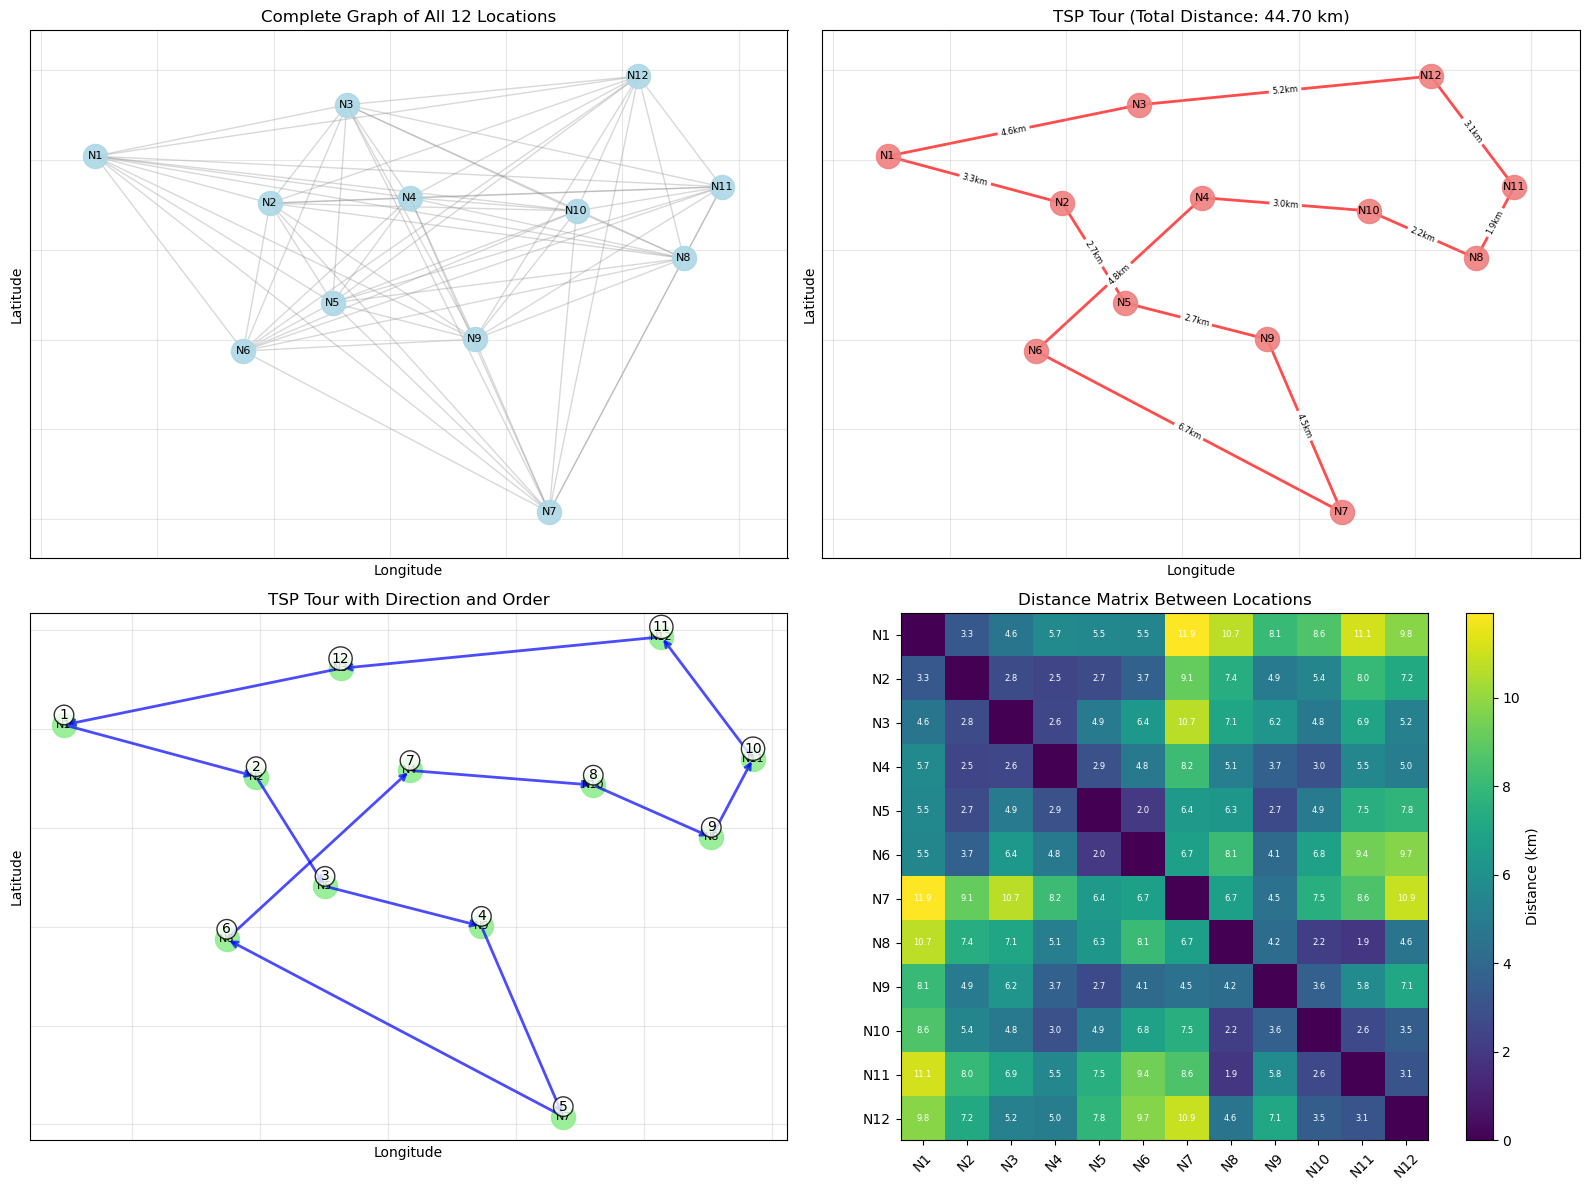


DETAILED ANALYSIS

Location Coordinates:
N1: HKUST - Lat: 22.340776, Lon: 114.269356
N2: Shelter Island Beach - Lat: 22.330317, Lon: 114.299397
N3: Kau Sai Wan beach - Lat: 22.352188, Lon: 114.312593
N4: Jin Island Sea Arch - Lat: 22.331554, Lon: 114.323446
N5: Green Egg Island - Lat: 22.308151, Lon: 114.310164
N6: Clear Water Bay Beach - Lat: 22.297451, Lon: 114.294800
N7: Ninepin Island Arch - Lat: 22.261611, Lon: 114.347414
N8: Basalt Island Sea Arch - Lat: 22.318040, Lon: 114.370563
N9: Mid-channel Point - Lat: 22.300064, Lon: 114.334617
N10: Bluff Island Beach - Lat: 22.328600, Lon: 114.352110
N11: Wang Chau Sea Arch - Lat: 22.333960, Lon: 114.377086
N12: Pak Lap Wan Beach - Lat: 22.358569, Lon: 114.362753

Tour Statistics:
Total distance: 44.70 km
Average distance between consecutive points: 3.73 km
Longest segment: N7 -> N6: 6.72 km
Shortest segment: N8 -> N11: 1.89 km


In [23]:
# Write your code here

import math
from itertools import combinations

coordinates = {
    'N1': (22.340776453179487, 114.26935593178568),    # HKUST
    'N2': (22.330316621251946, 114.29939665422496),    # Shelter Island Beach
    'N3': (22.352188002092156, 114.31259314107676),    # Kau Sai Wan beach
    'N4': (22.33155415026504, 114.32344615417998),     # Jin Island Sea Arch
    'N5': (22.308150981100766, 114.31016386250194),    # Green Egg Island
    'N6': (22.297450508467854, 114.2948001758139),     # Clear Water Bay Beach
    'N7': (22.261610882554226, 114.34741438377455),    # Ninepin Island Arch
    'N8': (22.318040484134386, 114.37056327643741),    # Basalt Island Sea Arch
    'N9': (22.300064054238113, 114.33461702139756),    # Mid-channel Point
    'N10': (22.328600460021025, 114.35210968586337),   # Bluff Island Beach
    'N11': (22.333959541308516, 114.37708639972803),   # Wang Chau Sea Arch
    'N12': (22.358568874944915, 114.36275264593087)    # Pak Lap Wan Beach
}

location_names = {
    'N1': 'HKUST',
    'N2': 'Shelter Island Beach',
    'N3': 'Kau Sai Wan beach',
    'N4': 'Jin Island Sea Arch',
    'N5': 'Green Egg Island',
    'N6': 'Clear Water Bay Beach',
    'N7': 'Ninepin Island Arch',
    'N8': 'Basalt Island Sea Arch',
    'N9': 'Mid-channel Point',
    'N10': 'Bluff Island Beach',
    'N11': 'Wang Chau Sea Arch',
    'N12': 'Pak Lap Wan Beach'
}

def haversine_distance(coord1, coord2):
    """
    Calculate the great-circle distance between two points 
    on the Earth (specified in decimal degrees)
    """
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    r = 6371 
    return c * r

G = nx.Graph()

for node, coord in coordinates.items():
    G.add_node(node, pos=coord, name=location_names[node])

for node1, node2 in combinations(coordinates.keys(), 2):
    dist = haversine_distance(coordinates[node1], coordinates[node2])
    G.add_edge(node1, node2, weight=dist)

best_tour = nx.approximation.traveling_salesman_problem(G, cycle=True)

total_distance = 0
for i in range(len(best_tour) - 1):
    total_distance += G[best_tour[i]][best_tour[i+1]]['weight']

print("Shortest Tour Sequence:")
for i, node in enumerate(best_tour[:-1]):
    next_node = best_tour[i+1]
    dist = G[node][next_node]['weight']
    print(f"{i+1}. {node} ({location_names[node]}) -> {next_node} ({location_names[next_node]}) : {dist:.2f} km")
print(f"\nTotal Distance: {total_distance:.2f} km")

plt.figure(figsize=(16, 12))

pos = {node: (coord[1], coord[0]) for node, coord in coordinates.items()} 

# Plot 1: Complete graph
plt.subplot(2, 2, 1)
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue', alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Complete Graph of All 12 Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)

# Plot 2: TSP Tour
plt.subplot(2, 2, 2)
# Draw the tour path
tour_edges = [(best_tour[i], best_tour[i+1]) for i in range(len(best_tour)-1)]
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightcoral', alpha=0.9)
nx.draw_networkx_edges(G, pos, edgelist=tour_edges, width=2, edge_color='red', alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=8)

edge_labels = {(best_tour[i], best_tour[i+1]): f"{G[best_tour[i]][best_tour[i+1]]['weight']:.1f}km" 
               for i in range(len(best_tour)-1)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title(f"TSP Tour (Total Distance: {total_distance:.2f} km)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)

# Plot 3: TSP Tour with arrows showing direction
plt.subplot(2, 2, 3)
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightgreen', alpha=0.9)

for i in range(len(best_tour)-1):
    start = pos[best_tour[i]]
    end = pos[best_tour[i+1]]
    plt.annotate("", xy=end, xytext=start, 
                arrowprops=dict(arrowstyle="->", color="blue", lw=2, alpha=0.7))

nx.draw_networkx_labels(G, pos, font_size=8)

for i, node in enumerate(best_tour[:-1]):
    plt.text(pos[node][0], pos[node][1] + 0.002, str(i+1), 
             fontsize=10, ha='center', va='center', 
             bbox=dict(boxstyle="circle,pad=0.2", facecolor="white", alpha=0.8))

plt.title("TSP Tour with Direction and Order")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)

# Plot 4: Distance matrix heatmap
plt.subplot(2, 2, 4)
nodes = list(coordinates.keys())
dist_matrix = np.zeros((len(nodes), len(nodes)))

for i, node1 in enumerate(nodes):
    for j, node2 in enumerate(nodes):
        if i != j:
            dist_matrix[i][j] = haversine_distance(coordinates[node1], coordinates[node2])

plt.imshow(dist_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Distance (km)')
plt.xticks(range(len(nodes)), nodes, rotation=45)
plt.yticks(range(len(nodes)), nodes)
plt.title("Distance Matrix Between Locations")

# Add distance values to heatmap
for i in range(len(nodes)):
    for j in range(len(nodes)):
        if i != j:
            plt.text(j, i, f'{dist_matrix[i, j]:.1f}', 
                    ha="center", va="center", color="white", fontsize=6)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DETAILED ANALYSIS")
print("="*80)

print("\nLocation Coordinates:")
for node, (lat, lon) in coordinates.items():
    print(f"{node}: {location_names[node]} - Lat: {lat:.6f}, Lon: {lon:.6f}")

print(f"\nTour Statistics:")
print(f"Total distance: {total_distance:.2f} km")
print(f"Average distance between consecutive points: {total_distance/(len(best_tour)-1):.2f} km")

# Find longest and shortest segments
segment_distances = []
for i in range(len(best_tour)-1):
    dist = G[best_tour[i]][best_tour[i+1]]['weight']
    segment_distances.append((best_tour[i], best_tour[i+1], dist))

longest_segment = max(segment_distances, key=lambda x: x[2])
shortest_segment = min(segment_distances, key=lambda x: x[2])

print(f"Longest segment: {longest_segment[0]} -> {longest_segment[1]}: {longest_segment[2]:.2f} km")
print(f"Shortest segment: {shortest_segment[0]} -> {shortest_segment[1]}: {shortest_segment[2]:.2f} km")